In [10]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [4]:
device = ("mps")

In [5]:
input_image = torch.rand(3,28,28)

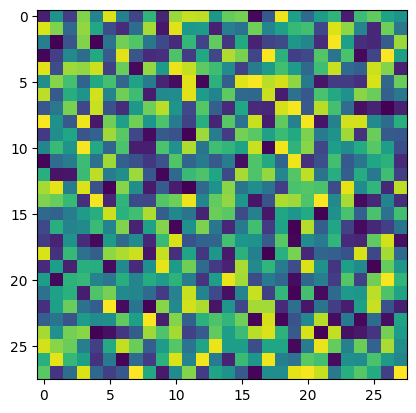

In [9]:
plt.imshow(input_image[2,...])

In [19]:
flatten = nn.Flatten()
flat_image = flatten(input_image)

In [20]:
flat_image.size()

torch.Size([3, 784])

In [21]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)

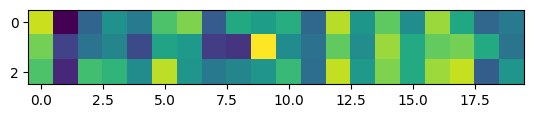

In [26]:
plt.imshow(hidden1.detach())

In [33]:
flat_image.size(), layer1.weight.size()

(torch.Size([3, 784]), torch.Size([20, 784]))

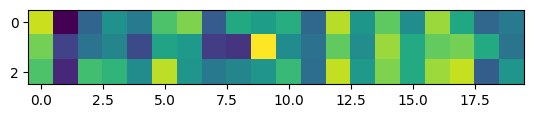

In [47]:
plt.imshow(((flat_image @ layer1.weight.T) + layer1.bias).detach())

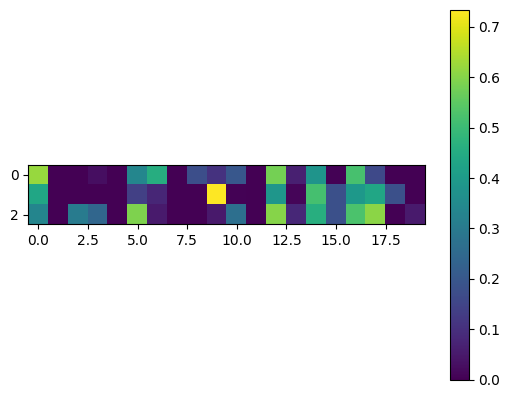

In [50]:
im = plt.imshow(nn.ReLU()(hidden1).detach())
plt.colorbar(im)

In [63]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20,100)
)

In [64]:
logits = seq_modules(input_image)

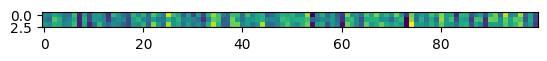

In [65]:
plt.imshow(logits.detach())

In [66]:
logits.max()

tensor(0.5366, grad_fn=<MaxBackward1>)

In [74]:
nn.Softmax()(logits)

/Users/tadzio/git/procedural-painting/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1553: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.0094, 0.0090, 0.0107, 0.0098, 0.0084, 0.0084, 0.0117, 0.0061, 0.0104,
         0.0070, 0.0099, 0.0100, 0.0087, 0.0064, 0.0115, 0.0099, 0.0083, 0.0074,
         0.0114, 0.0096, 0.0111, 0.0082, 0.0123, 0.0103, 0.0088, 0.0158, 0.0118,
         0.0108, 0.0077, 0.0101, 0.0070, 0.0100, 0.0070, 0.0110, 0.0142, 0.0120,
         0.0087, 0.0080, 0.0118, 0.0116, 0.0083, 0.0120, 0.0094, 0.0106, 0.0112,
         0.0075, 0.0082, 0.0097, 0.0111, 0.0106, 0.0112, 0.0096, 0.0098, 0.0142,
         0.0054, 0.0093, 0.0110, 0.0083, 0.0102, 0.0076, 0.0066, 0.0135, 0.0092,
         0.0098, 0.0083, 0.0123, 0.0108, 0.0134, 0.0102, 0.0113, 0.0096, 0.0131,
         0.0098, 0.0065, 0.0134, 0.0089, 0.0102, 0.0093, 0.0120, 0.0105, 0.0138,
         0.0104, 0.0108, 0.0063, 0.0114, 0.0112, 0.0075, 0.0086, 0.0102, 0.0074,
         0.0110, 0.0131, 0.0082, 0.0153, 0.0094, 0.0097, 0.0145, 0.0080, 0.0104,
         0.0070],
        [0.0090, 0.0081, 0.0127, 0.0112, 0.0088, 0.0094, 0.0112, 0.0061, 0.0112,
         0